<a href="https://colab.research.google.com/github/rjlobosco/uenf/blob/main/uenf_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install cdsapi
%pip install netcdf4

import cdsapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.7 MB/s eta 0:00:00


In [ ]:

dataset = "reanalysis-era5-single-levels"
request = {
    "variable": "2m_temperature", # Changed from list to string
    "year": "2024",             # Changed from list to string
    "month": "05",            # Changed from list to string
    "day": "01",              # Changed from list to string
    "time": "19:00",            # Changed from list to string
    "format": "netcdf",
    "area": [90, -180, -90, 180]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='83dbd0a2-6dc2-4406-ba2f-ebb558e108f6', verify=False)
client.retrieve(dataset, request).download()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-01 17:43:08,702 INFO Request 

e24aead7923d5cecda5b3f2b75ba5d89.nc:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'e24aead7923d5cecda5b3f2b75ba5d89.nc'

In [ ]:
# Colab only
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import xarray as xr
import pandas as pd

In [ ]:

ds = xr.open_dataset('/content/drive/MyDrive/uenf_test.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('Dataset converted to DataFrame and saved to output_data_irradiance.csv')


Dataset converted to DataFrame and saved to output_data_irradiance.csv


In [ ]:
df_converted

t2m  number expver
valid_time          latitude longitude                           
2024-02-01 19:00:00  90.0    -180.00    263.121521       0   0001
                             -179.75    263.121521       0   0001
                             -179.50    263.121521       0   0001
                             -179.25    263.121521       0   0001
                             -179.00    263.121521       0   0001
...                                            ...     ...    ...
                    -90.0     178.75    236.803162       0   0001
                              179.00    236.803162       0   0001
                              179.25    236.803162       0   0001
                              179.50    236.803162       0   0001
                              179.75    236.803162       0   0001

[1038240 rows x 3 columns]

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 69.8 MB/s eta 0:00:00


ValueError: too many values to unpack (expected 4)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWar

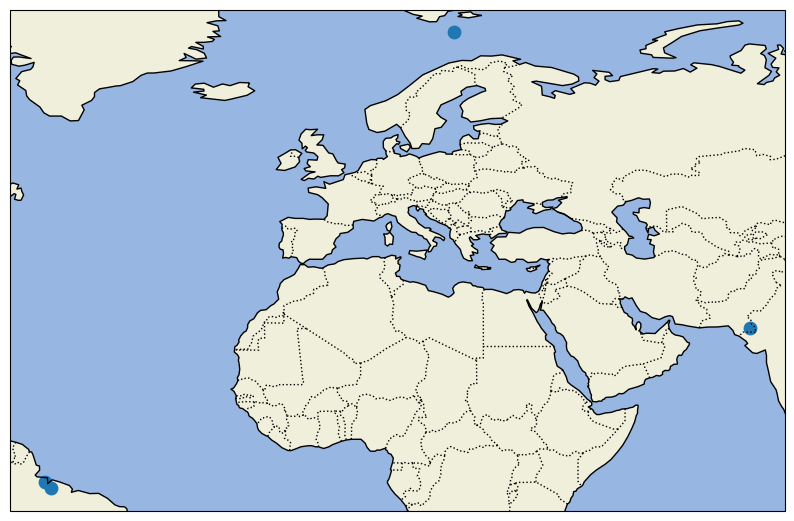

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example latitude and longitude data
latitudes = [-1,75, -2,25]
longitudes = [-49,20, -48,70]


# Create figure
plt.figure(figsize=(10, 8))

# Map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot points
ax.scatter(
    longitudes,
    latitudes,
    s=80,
    marker='o',
    transform=ccrs.PlateCarree(),
    label='Locations'
)

# Define map extent: [min_lon, max_lon, min_lat, max_lat]
ax.set_extent([-1,75, -2,25, -49,20, -48,70], crs=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Title and legend
plt.title("Latitude and Longitude Points")
plt.legend()

plt.show()

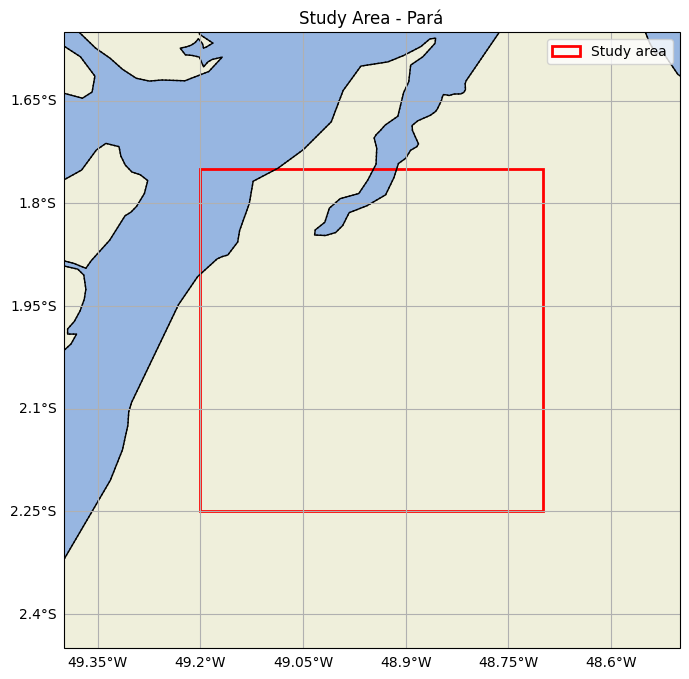

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

# Coordinates of the region
lat_north = -1.75
lat_south = -2.25
lon_west = -49.20
lon_east = -48.70

# Create figure
plt.figure(figsize=(10, 8))

# Map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Define map extent with margin
ax.set_extent(
    [lon_west - 0.2, lon_east + 0.2, lat_south - 0.2, lat_north + 0.2],
    crs=ccrs.PlateCarree()
)

# Add rectangle representing the study region
rect = Rectangle(
    (lon_west, lat_south),
    lon_east - lon_west,
    lat_north - lat_south,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    label='Study area'
)

ax.add_patch(rect)

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Title and legend
plt.title("Study Area - Pará")
plt.legend()

plt.show()

In [ ]:
import xarray as xr
import pandas as pd

ds_BHI = xr.open_dataset('v4.5_BHI_clear_2011_01.area-subset.-21.-39.-24.-42.nc',engine='h5netcdf')
ds_BNI = xr.open_dataset('v4.5_BNI_clear_2011_01.area-subset.-21.-39.-24.-42.nc',engine='h5netcdf')


df_converted_BHI = ds_BHI.to_dataframe()
df_converted_BNI = ds_BNI.to_dataframe()

df_combined = pd.concat([df_converted_BHI, df_converted_BNI], axis=1)
df_combined.columns = ['BHI', 'BNI']

df_combined.to_csv('output_data_irradiance.csv', index=True)
print('Dataset converted to DataFrame and saved to output_data_irradiance.csv')

In [ ]:
import pandas as pd

df = pd.read_csv("file.csv")

print(df)

FileNotFoundError: [Errno 2] No such file or directory: 'file.csv'